# 03_entropy_crossentropy_weighting_codes.ipynb

本 notebook 生成第 3 篇推文所需的插图和模拟数据。

输出文件：

- `./figs/entropy_cross_fig01_log_loss.png`
- `./figs/entropy_cross_fig02_ce_kl_relation.png`
- `./figs/entropy_cross_fig03_balance_before_after.png`
- `./figs/entropy_cross_fig04_weight_distribution.png`
- `./data/entropy_cross_weighting_sim.csv`


In [12]:
import os
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# 创建输出文件夹：figs 存放插图，data 存放模拟数据或示例数据
FIG_DIR = Path('./figs')
DATA_DIR = Path('./data')
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# ── Matplotlib 中文字体与通用样式 ──────────────────────────────
# Windows 本地优先使用 SimHei；Linux/macOS 环境下尝试注册 Noto CJK 字体文件。
# 注意：标题中的 log_2 不使用 Unicode 下标，而使用 mathtext，避免出现底数乱码。
import matplotlib.font_manager as fm

if platform.system() == 'Windows':
    FONT_FAMILY = 'SimHei'
else:
    font_candidates = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
        '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
        '/System/Library/Fonts/PingFang.ttc',
    ]
    FONT_FAMILY = 'DejaVu Sans'
    for font_path in font_candidates:
        if Path(font_path).exists():
            fm.fontManager.addfont(font_path)
            FONT_FAMILY = fm.FontProperties(fname=font_path).get_name()
            break

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [FONT_FAMILY, 'SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 240,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
})

# 统一色板。为了便于后续维护，所有图片尽量使用同一组颜色。
COLORS = {
    'blue':   '#2C7FB8',
    'green':  '#41AB5D',
    'orange': '#F28E2B',
    'red':    '#D95F5F',
    'purple': '#7B6FD6',
    'gray':   '#666666',
    'light':  '#F5F7FA',
    'dark':   '#263238',
}

def savefig(name, tight=True):
    """统一保存图片，避免每个代码块重复写路径。"""
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f'已保存: {path}')

from scipy.optimize import root


In [13]:
def entropy(prob):
    """离散概率分布的 Shannon entropy。"""
    prob = np.asarray(prob, dtype=float)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def cross_entropy(P, Q):
    """交叉熵 H(P,Q)。"""
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    mask = P > 0
    return -np.sum(P[mask] * np.log2(Q[mask]))

def kl_div(P, Q):
    """KL 散度 D_KL(P||Q)。"""
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    mask = P > 0
    return np.sum(P[mask] * np.log2(P[mask] / Q[mask]))


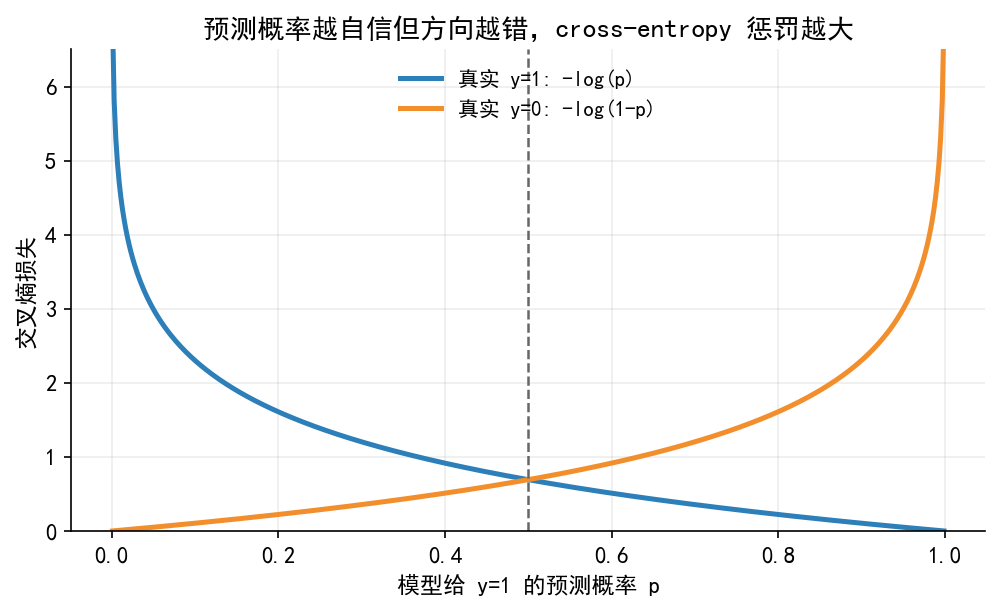

已保存: figs\entropy_cross_fig01_log_loss.png


In [14]:
# 图 1：二分类交叉熵损失。
# 当真实 y=1 时，预测概率 p 越接近 1，损失越小；越接近 0，损失急剧上升。
p = np.linspace(0.001, 0.999, 500)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(p, loss_y1, lw=2.4, color=COLORS['blue'], label='真实 y=1: -log(p)')
ax.plot(p, loss_y0, lw=2.4, color=COLORS['orange'], label='真实 y=0: -log(1-p)')
ax.axvline(0.5, color=COLORS['gray'], lw=1.2, ls='--')
ax.set_ylim(0, 6.5)
ax.set_xlabel('模型给 y=1 的预测概率 p')
ax.set_ylabel('交叉熵损失')
ax.set_title('预测概率越自信但方向越错，cross-entropy 惩罚越大')
ax.legend(frameon=False, loc='upper center')
savefig('entropy_cross_fig01_log_loss.png')


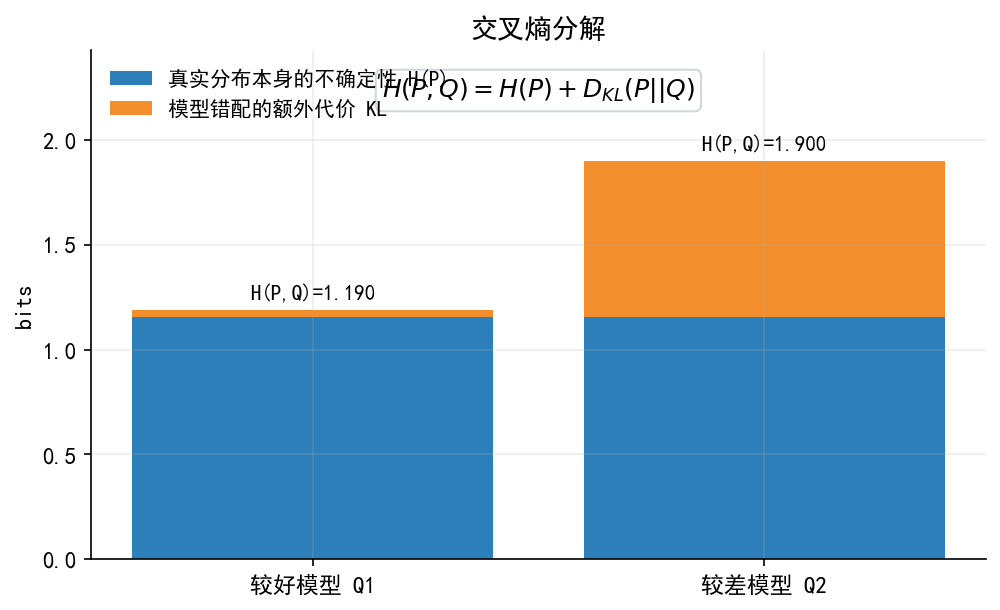

已保存: figs\entropy_cross_fig02_ce_kl_relation.png


In [15]:
# 图 2：熵、交叉熵与 KL 散度的分解关系。
P = np.array([0.70, 0.20, 0.10])
Q_good = np.array([0.60, 0.25, 0.15])
Q_bad = np.array([0.25, 0.25, 0.50])

rows = []
for name, Q in [('较好模型 Q1', Q_good), ('较差模型 Q2', Q_bad)]:
    rows.append({
        'model': name,
        'H(P)': entropy(P),
        'D_KL(P||Q)': kl_div(P, Q),
        'H(P,Q)': cross_entropy(P, Q),
    })
decomp = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
x = np.arange(len(decomp))
ax.bar(x, decomp['H(P)'], color=COLORS['blue'], label='真实分布本身的不确定性 H(P)')
ax.bar(x, decomp['D_KL(P||Q)'], bottom=decomp['H(P)'], color=COLORS['orange'], label='模型错配的额外代价 KL')

for i, row in decomp.iterrows():
    ax.text(i, row['H(P,Q)'] + 0.035, f"H(P,Q)={row['H(P,Q)']:.3f}",
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(decomp['model'])
ax.set_ylabel('bits')
ax.set_title('交叉熵分解')
ax.text(0.50, 0.92, r'$H(P,Q)=H(P)+D_{KL}(P||Q)$', transform=ax.transAxes,
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D7DE'))
ax.legend(frameon=False, loc='upper left')
ax.set_ylim(0, decomp['H(P,Q)'].max() * 1.28)
savefig('entropy_cross_fig02_ce_kl_relation.png')


In [16]:
# 构造一个处理组和控制组协变量不平衡的模拟样本。
# entropy balancing 的目标是：给控制组赋权，使其加权后的协变量均值等于处理组均值。
rng = np.random.default_rng(20260429)
n_t, n_c = 120, 360

# 处理组在 x1、x2 上整体更高；控制组与处理组初始不可比。
x_t = rng.multivariate_normal(mean=[0.65, 0.55], cov=[[1.00, 0.25], [0.25, 1.00]], size=n_t)
x_c = rng.multivariate_normal(mean=[-0.10, -0.10], cov=[[1.10, 0.20], [0.20, 0.90]], size=n_c)

df_t = pd.DataFrame(x_t, columns=['x1', 'x2'])
df_t['D'] = 1
df_c = pd.DataFrame(x_c, columns=['x1', 'x2'])
df_c['D'] = 0

# 为了让约束包括均值，同时不过度复杂，这里只平衡 x1 与 x2 的一阶矩。
Xc = df_c[['x1', 'x2']].to_numpy()
target = df_t[['x1', 'x2']].mean().to_numpy()

# 采用指数倾斜形式求解权重：w_i ∝ exp(lambda' X_i)。
# root 函数求 lambda，使加权均值等于处理组均值。
def moment_equations(lam):
    score = Xc @ lam
    score = score - score.max()  # 数值稳定处理
    w = np.exp(score)
    w = w / w.sum()
    return w @ Xc - target

sol = root(moment_equations, x0=np.zeros(Xc.shape[1]))
lam = sol.x
score = Xc @ lam
score = score - score.max()
w_c = np.exp(score)
w_c = w_c / w_c.sum() * len(w_c)  # 均值约为 1，便于解释

df_c['w_eb'] = w_c
df_t['w_eb'] = 1.0
sim = pd.concat([df_t, df_c], ignore_index=True)
sim.to_csv(DATA_DIR / 'entropy_cross_weighting_sim.csv', index=False, encoding='utf-8-sig')

# 计算标准化均值差异 SMD。
def smd_unweighted(var):
    mt = sim.loc[sim.D == 1, var].mean()
    mc = sim.loc[sim.D == 0, var].mean()
    vt = sim.loc[sim.D == 1, var].var(ddof=1)
    vc = sim.loc[sim.D == 0, var].var(ddof=1)
    sp = np.sqrt((vt + vc) / 2)
    return (mt - mc) / sp

def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

def smd_weighted_control(var):
    mt = sim.loc[sim.D == 1, var].mean()
    control = sim.loc[sim.D == 0, [var, 'w_eb']]
    mc = weighted_mean(control[var].to_numpy(), control['w_eb'].to_numpy())
    vt = sim.loc[sim.D == 1, var].var(ddof=1)
    vc = sim.loc[sim.D == 0, var].var(ddof=1)
    sp = np.sqrt((vt + vc) / 2)
    return (mt - mc) / sp

balance = pd.DataFrame({
    'variable': ['x1', 'x2'],
    'Before': [abs(smd_unweighted('x1')), abs(smd_unweighted('x2'))],
    'After':  [abs(smd_weighted_control('x1')), abs(smd_weighted_control('x2'))],
})
print(balance)
print('lambda =', lam)


  variable    Before         After
0       x1  0.622844  2.757325e-14
1       x2  0.663413  2.560699e-14
lambda = [0.43332868 0.66039286]


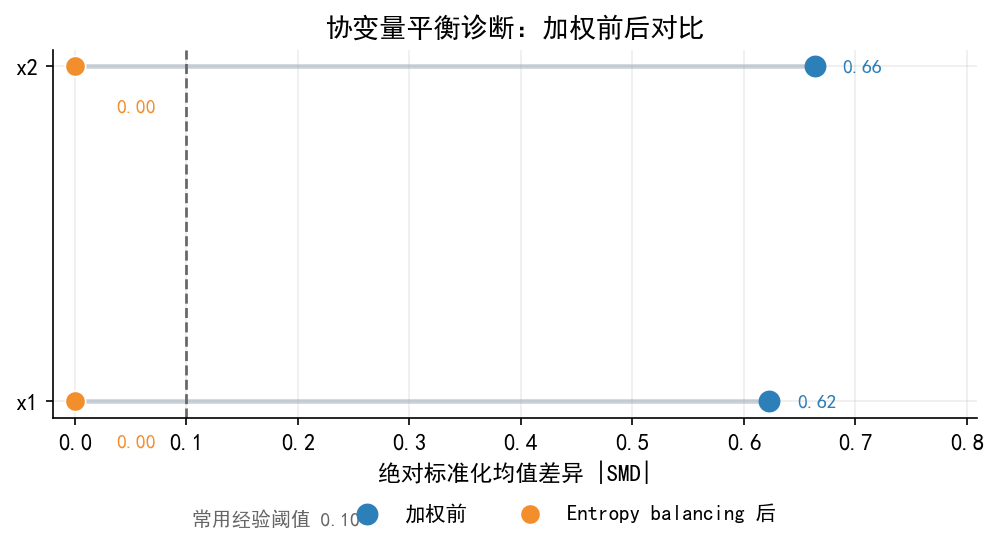

已保存: figs\entropy_cross_fig03_balance_before_after.png


In [17]:
# 图 3：Love plot 风格的平衡诊断图。
# 相比柱状图，点线图能更清楚地看到加权后是否低于经验阈值 0.10。
fig, ax = plt.subplots(figsize=(6.8, 3.9))
y = np.arange(len(balance))

ax.hlines(y, balance['After'], balance['Before'], color='#C9D1D9', lw=2.2, zorder=1)
ax.scatter(balance['Before'], y, s=90, color=COLORS['blue'], label='加权前', zorder=3)
ax.scatter(balance['After'], y, s=95, color=COLORS['orange'], label='Entropy balancing 后', zorder=4, edgecolor='white', linewidth=0.8)
ax.axvline(0.10, color=COLORS['gray'], ls='--', lw=1.3)
ax.text(0.105, -0.35, '常用经验阈值 0.10', fontsize=9.5, color=COLORS['gray'], ha='left', va='center')

for i, row in balance.iterrows():
    ax.text(row['Before'] + 0.025, i, f"{row['Before']:.2f}", va='center', fontsize=9.5, color=COLORS['blue'])
    ax.text(max(row['After'], 0.012) + 0.025, i - 0.12, f"{row['After']:.2f}", va='center', fontsize=9.5, color=COLORS['orange'])

ax.set_yticks(y)
ax.set_yticklabels(balance['variable'])
ax.set_xlabel('绝对标准化均值差异 |SMD|')
ax.set_xlim(-0.02, max(balance['Before']) * 1.22)
ax.set_title('协变量平衡诊断：加权前后对比')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.55, -0.18), ncol=2)
savefig('entropy_cross_fig03_balance_before_after.png')


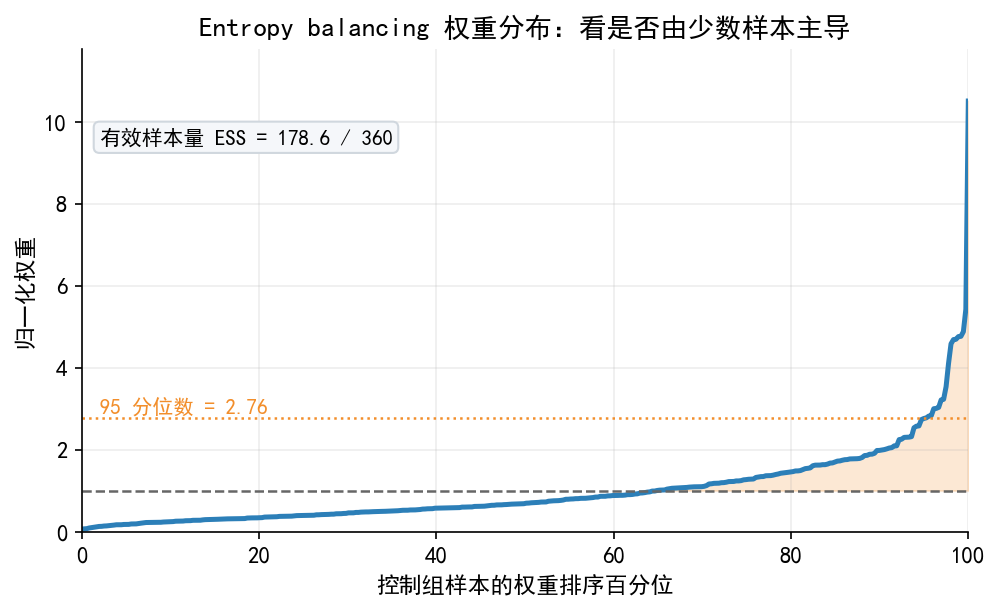

已保存: figs\entropy_cross_fig04_weight_distribution.png


In [18]:
# 图 4：权重诊断图。
# 使用排序后的归一化权重展示是否存在少数样本权重过大。
control_w = sim.loc[sim.D == 0, 'w_eb'].to_numpy()
w_sorted = np.sort(control_w)
rank = np.linspace(0, 100, len(w_sorted))
ess = (control_w.sum() ** 2) / np.sum(control_w ** 2)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(rank, w_sorted, color=COLORS['blue'], lw=2.4)
ax.axhline(1.0, color=COLORS['gray'], lw=1.2, ls='--')
ax.fill_between(rank, w_sorted, 1.0, where=w_sorted >= 1.0, color=COLORS['orange'], alpha=0.20)

p95 = np.percentile(control_w, 95)
ax.axhline(p95, color=COLORS['orange'], lw=1.2, ls=':')
ax.text(2, p95 + 0.06, f'95 分位数 = {p95:.2f}', color=COLORS['orange'], fontsize=10, va='bottom')
ax.text(2, max(w_sorted) * 0.90, f'有效样本量 ESS = {ess:.1f} / {len(control_w)}', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.28', facecolor='#F5F7FA', edgecolor='#D0D7DE'))

ax.set_xlabel('控制组样本的权重排序百分位')
ax.set_ylabel('归一化权重')
ax.set_title('Entropy balancing 权重分布：看是否由少数样本主导')
ax.set_xlim(0, 100)
ax.set_ylim(0, max(w_sorted) * 1.12)
savefig('entropy_cross_fig04_weight_distribution.png')
